In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()

        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.d_v = self.d_k

        # Linear projections
        self.linear_q = nn.Linear(d_model, self.d_k * num_heads)
        self.linear_k = nn.Linear(d_model, self.d_k * num_heads)
        self.linear_v = nn.Linear(d_model, self.d_v * num_heads)

        self.linear_out = nn.Linear(self.d_v * num_heads, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):

        batch_size = query.size(0)

        # Linear projections
        Q = self.linear_q(query)
        K = self.linear_k(key)
        V = self.linear_v(value)

        # Split into heads
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_v).transpose(1, 2)

        # Scaled dot-product attention
        output, attention_weights = scaled_dot_product_attention(
            Q, K, V, mask, self.dropout
        )

        # Concatenate heads
        output = (
            output.transpose(1, 2)
            .contiguous()
            .view(batch_size, -1, self.d_v * self.num_heads)
        )

        # Final linear projection
        output = self.linear_out(output)

        return output


def scaled_dot_product_attention(query, key, value, mask=None, dropout=None):

    d_k = query.size(-1)

    # Compute attention scores
    scores = torch.einsum("bhqd,bhkd->bhqk", query, key) / (d_k ** 0.5)

    # Apply mask
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))

    # Softmax
    attention_weights = F.softmax(scores, dim=-1)

    # Dropout
    if dropout is not None:
        attention_weights = dropout(attention_weights)

    # Weighted sum
    output = torch.matmul(attention_weights, value)

    return output, attention_weights


# =============================
# Example Usage
# =============================

if __name__ == "__main__":

    batch_size = 2
    seq_len = 4
    d_model = 512
    num_heads = 8

    # Create model
    mha = MultiHeadAttention(d_model, num_heads)

    # Random inputs
    query = torch.randn(batch_size, seq_len, d_model)
    key = torch.randn(batch_size, seq_len, d_model)
    value = torch.randn(batch_size, seq_len, d_model)

    # Optional mask (all allowed here)
    mask = torch.ones(batch_size, 1, seq_len, seq_len)

    # Forward pass
    output = mha(query, key, value, mask)

    print("Output shape:", output.shape)


Output shape: torch.Size([2, 4, 512])


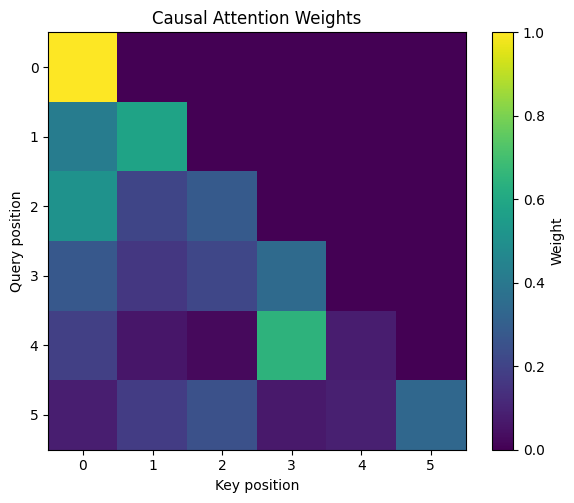

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


# -----------------------------
# Causal mask function
# -----------------------------
def subsequent_mask(size):
    attn_shape = (1, size, size)

    mask = torch.triu(torch.ones(attn_shape), diagonal=1).bool()

    return ~mask   # True = allowed, False = blocked


# -----------------------------
# Scaled Dot-Product Attention
# -----------------------------
def scaled_dot_product_attention(query, key, value, mask=None):

    d_k = query.size(-1)

    scores = torch.matmul(query, key.transpose(-2, -1)) / (d_k ** 0.5)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))

    attn_weights = F.softmax(scores, dim=-1)

    output = torch.matmul(attn_weights, value)

    return output, attn_weights


# -----------------------------
# Example: Visualize Attention
# -----------------------------

# Settings
seq_len = 6
d_k = 4
batch = 1
heads = 1   # Dummy single head

# Create random Q, K, V
q = torch.randn(batch, heads, seq_len, d_k)
k = torch.randn(batch, heads, seq_len, d_k)
v = torch.randn(batch, heads, seq_len, d_k)

# Causal mask
mask = subsequent_mask(seq_len)        # (1, seq, seq)
mask = mask.unsqueeze(1)               # (1, 1, seq, seq)

# Run attention
output, attn_weights = scaled_dot_product_attention(q, k, v, mask)

# Remove batch & head dims: (1,1,seq,seq) → (seq,seq)
attn = attn_weights[0, 0].detach().numpy()


# -----------------------------
# Plot Heatmap
# -----------------------------

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(attn, aspect="equal", vmin=0, vmax=1)

ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))

ax.set_xlabel("Key position")
ax.set_ylabel("Query position")
ax.set_title("Causal Attention Weights")

plt.colorbar(im, ax=ax, label="Weight")

plt.tight_layout()
plt.show()
